First things first, we need to get the Black-Scholes **true** price of an option, as well as all the greeks.

In [1]:
from scipy.stats import norm                                              # norm gives us norm.cdf(x) = N(x) (area under bell curve to left of x) and norm.pdf(x) = φ(x) (bell curve height at x), every Black-Scholes formula uses these two functions
import numpy as np                                                        

def bs_price(S, K, T, r, sigma, option_type="call"):                     # price a European option using the Black-Scholes closed-form; European means exercise only at expiry T, not before
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))       # d1: the standardised log-moneyness for the stock leg; np.log(S/K) = log-moneyness (0 at ATM, positive if ITM for a call); (r+σ²/2)T = expected log-drift of the stock (Itô's σ²/2 correction: because log is concave, E[log S_T] = log S + (r-σ²/2)T not r·T); dividing by σ√T = standard deviation of log-returns converts to a z-score so we can use the normal CDF
    d2 = d1 - sigma*np.sqrt(T)                                           # d2 = d1 minus one standard deviation of log-returns; N(d2) equals the risk-neutral probability that S_T > K (the option finishes in the money); it's one σ√T below d1 because d2 corresponds to the strike-payment leg, not the stock leg
    if option_type == "call":
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)            # call value = stock leg minus strike leg; S·N(d1) = present value of the stock you receive conditional on S_T>K, probability-weighted; K·e^{-rT}·N(d2) = present value of the strike K you pay if you exercise (discounted from T to now, weighted by N(d2) = probability you actually pay it); net = fair option price
    else:
        return -S*norm.cdf(-d1) + K*np.exp(-r*T)*norm.cdf(-d2)         # put value: for a put you RECEIVE K and GIVE UP the stock so signs flip vs call; N(-d1)=1-N(d1), N(-d2)=1-N(d2); mathematically equivalent to call - S + K·e^{-rT} by put-call parity, simplified

def greeks(S, K, T, r, sigma, option_type="call"):                       # compute the five main Greeks, measuring sensitivity of option price to each input; traders use them to hedge and quantify risk
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))       # recompute d1 
    d2 = d1 - sigma*np.sqrt(T)                                           # recompute d2 

    call_delta = norm.cdf(d1)                                            # call delta = ∂C/∂S = N(d1); "if stock goes up $1, option gains delta dollars"; 0 = deep OTM (barely moves with stock), 1 = deep ITM (moves dollar-for-dollar like owning shares); also approximately the risk-neutral probability of expiring ITM
    put_delta  = norm.cdf(d1) - 1.0                                      # put delta = N(d1)-1 = -N(-d1); negative because puts GAIN when stock FALLS; delta = -0.5 means a $1 stock drop gains you $0.50 on the put

    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))                      # gamma = ∂²C/∂S² = ∂(delta)/∂S; how fast delta changes per $1 stock move; norm.pdf(d1) = bell-curve height, highest at d1=0 (ATM), so gamma peaks at-the-money; same for calls and puts (required by put-call parity); high gamma = delta hedge goes stale quickly, need to rebalance often

    vega = (S * np.sqrt(T) * norm.pdf(d1)) / 100                         # vega = ∂C/∂σ, scaled to $ per 1% vol change (dividing by 100 converts "per unit σ" to "per 1%"); longer T = higher vega (more time for vol to affect the outcome); peaks ATM; same for calls and puts

    call_theta = (-(S * norm.pdf(d1) * sigma) / (2*np.sqrt(T))          # call theta first term: -(S·φ(d1)·σ)/(2√T) = "gamma rent" := owning convexity costs money every day; the higher your gamma, the faster you burn time value; this is why option sellers love short-gamma positions: they collect this decay
                  - r * K * np.exp(-r*T) * norm.cdf(d2)) / 365           # call theta second term: -r·K·e^{-rT}·N(d2) = interest component, meaning that as time passes the PV of the strike you'd pay falls, reducing the call slightly; /365 converts annual theta to daily (traders always quote per day)
    put_theta  = (-(S * norm.pdf(d1) * sigma) / (2*np.sqrt(T))          # put theta first term: same gamma-rent as call, puts also bleed time value at the same convexity rate
                  + r * K * np.exp(-r*T) * norm.cdf(-d2)) / 365          # put theta second term: +r·K·e^{-rT}·N(-d2) (sign flips vs call); for a put you RECEIVE K on exercise so the rising PV of getting K slightly offsets decay; deep ITM puts can have positive theta

    call_rho = (K * T * np.exp(-r*T) * norm.cdf(d2)) / 100              # call rho = ∂C/∂r per 1% rate move; positive because higher rates increase the forward price S·e^{rT}, making calls worth more; K·T·e^{-rT} = duration of the strike payment, weighted by N(d2)
    put_rho  = (-K * T * np.exp(-r*T) * norm.cdf(-d2)) / 100            # put rho negative because higher rates hurt puts (forward price rises above strike, less likely to profit)

    if option_type == "call":
        return {"Delta": call_delta, "Gamma": gamma,                     # return a dict so callers can write greeks(...)["Delta"]
                "Theta": call_theta, "Vega": vega, "Rho": call_rho}
    else:
        return {"Delta": put_delta, "Gamma": gamma,
                "Theta": put_theta, "Vega": vega, "Rho": put_rho}


Since this is based on BS assumptions, we'd like to know if this model prices options correctly, and if MC correctly predicts this, then we can verify and also test our assumptions.

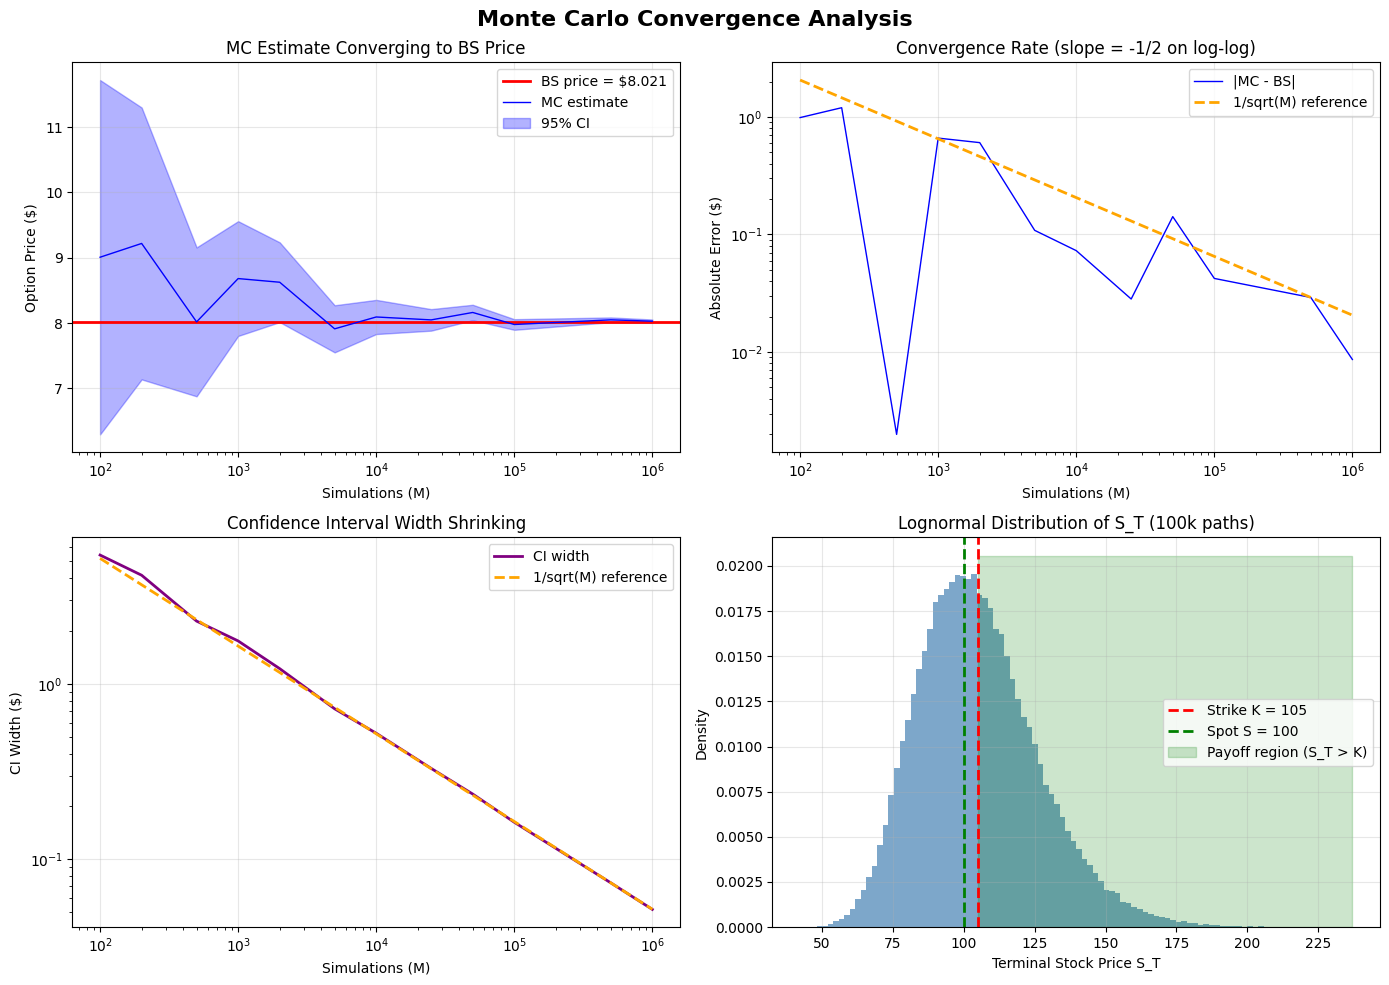

In [2]:
def monte_carlo_price(S, K, T, r, sigma, M=100000, option_type="call"):  # price an option by simulation: average M random payoffs and discount; converges to the exact BS price as M→∞ by Law of Large Numbers, without needing a closed-form formula
    Z = np.random.standard_normal(M)                                       # draw M independent N(0,1) random numbers; each Z_i is one possible Brownian motion shock from now to expiry 
    ST = S * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)           # simulate M terminal stock prices using GBM: S_T = S·exp((r-σ²/2)T + σ√T·Z); (r-σ²/2) is the Itô-corrected drift (without σ²/2 the expected log-price would be wrong); σ√T·Z gives the right std dev of log-returns; broadcasting over the M-element Z array gives M independent S_T values at once
    if option_type == "call":
        payoffs = np.maximum(ST - K, 0)                                    # call payoff = max(S_T - K, 0): only profitable if stock ends above strike; np.maximum is element-wise so this works on all M values simultaneously; S_T ≤ K paths contribute 0 (option worthless)
    else:
        payoffs = np.maximum(K - ST, 0)                                    # put payoff = max(K - S_T, 0): profitable when stock falls below strike K
    price = np.exp(-r*T) * np.mean(payoffs)                                # risk-neutral price = e^{-rT}·E^Q[payoff]; np.mean estimates the expectation as a sample average (Law of Large Numbers); e^{-rT} discounts the future payoff to present value i.e. $1 at time T is worth e^{-rT} today
    se    = np.exp(-r*T) * np.std(payoffs) / np.sqrt(M)                   # standard error = std/√M by CLT; measures statistical uncertainty; price ± 1.96·se = 95% CI; shrinks as 1/√M, halving error requires 4× as many paths
    return price, se, ST, payoffs                                           # return: price estimate, uncertainty (se), all terminal prices (for histogram), all payoffs (for analysis)

import matplotlib.pyplot as plt                                            # matplotlib for all the plots in this section

S, K, T, r, sigma = 100, 105, 1, 0.05, 0.2                               # test option: $100 stock, $105 strike (5% OTM), 1-year maturity, 5% rate, 20% vol
bs = bs_price(S, K, T, r, sigma, "call")                                  # exact BS price = the ground truth we compare MC against

M_values = [100, 200, 500, 1000, 2000, 5000, 10000,
            25000, 50000, 100000, 500000, 1000000]                         # simulation counts roughly doubling each time, log-spaced to match the 1/√M convergence rate
mc_prices    = []                                                           # MC price estimate at each M
lower_bounds = []                                                           # lower edge of 95% CI: price - 1.96·se
upper_bounds = []                                                           # upper edge of 95% CI: price + 1.96·se
errors       = []                                                           # actual error |MC - BS| at each M
ci_widths    = []                                                           # total CI width = 2·1.96·se

for M in M_values:
    price, se, _, _ = monte_carlo_price(S, K, T, r, sigma, M)             # run MC with M paths; _ discards ST and payoffs (not needed for convergence plots, only for the histogram below)
    mc_prices.append(price)
    lower_bounds.append(price - 1.96*se)                                   # 95% CI lower: 1.96 is the z-score s.t. P(-1.96<Z<1.96)=0.95
    upper_bounds.append(price + 1.96*se)                                   # 95% CI upper: symmetric around the estimate
    errors.append(abs(price - bs))                                          # actual error vs the known-correct BS price
    ci_widths.append(2 * 1.96 * se)                                        # full CI width

M_values     = np.array(M_values)      # convert to numpy arrays so we can use boolean indexing (M_values[nonzero]) and vector math (1/np.sqrt(M_values)) below
mc_prices    = np.array(mc_prices)
lower_bounds = np.array(lower_bounds)
upper_bounds = np.array(upper_bounds)
errors       = np.array(errors)
ci_widths    = np.array(ci_widths)

_, _, ST_large, _ = monte_carlo_price(S, K, T, r, sigma, M=100000)       # big run just for the terminal-price histogram; 100k gives smooth lognormal curve; _ discards everything except ST

fig, axes = plt.subplots(2, 2, figsize=(14, 10))                          # 2×2 subplot grid; 4 panels show different aspects of MC convergence
fig.suptitle('Monte Carlo Convergence Analysis', fontsize=16, fontweight='bold')

ax = axes[0, 0]                                                            # top-left panel: MC estimate vs BS as M grows
ax.axhline(bs, color='red', linewidth=2, label=f'BS price = ${bs:.3f}')  # red horizontal = true BS price; the target the MC estimate converges toward
ax.plot(M_values, mc_prices, color='blue', linewidth=1, label='MC estimate')  # blue line = MC estimates; wiggles at low M, settles near true price at high M
ax.fill_between(M_values, lower_bounds, upper_bounds,
                alpha=0.3, color='blue', label='95% CI')                  # blue band = 95% CI; watch it narrow as M grows by Law of Large Numbers
ax.set_xscale('log')                                                       # log x-axis because M spans 4 orders of magnitude
ax.set_xlabel('Simulations (M)')
ax.set_ylabel('Option Price ($)')
ax.set_title('MC Estimate Converging to BS Price')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]                                                            # top-right: error on log-log scale (convergence rate panel)
nonzero = errors > 0                                                       # skip zero errors since log(0)=-∞ crashes loglog
ax.loglog(M_values[nonzero], errors[nonzero],
          color='blue', linewidth=1, label='|MC - BS|')                   # loglog: power law y=C·M^n → straight line with slope n; expect slope -0.5 because MC error ∝ M^{-1/2}
scale = errors[nonzero][10] * np.sqrt(M_values[nonzero][10])              # calibrate reference line at index 10: C = error·√M at that point
ax.loglog(M_values[nonzero], scale / np.sqrt(M_values[nonzero]),
          color='orange', linestyle='--', linewidth=2, label='1/sqrt(M) reference')  # dashed orange = theoretical 1/√M rate; if blue tracks this, we're at optimal convergence
ax.set_xlabel('Simulations (M)')
ax.set_ylabel('Absolute Error ($)')
ax.set_title('Convergence Rate (slope = -1/2 on log-log)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]                                                            # bottom-left: CI width shrinking
ax.loglog(M_values, ci_widths, color='purple', linewidth=2, label='CI width')  # CI width = 2·1.96·std/√M also shrinks as 1/√M 
scale2 = ci_widths[10] * np.sqrt(M_values[10])
ax.loglog(M_values, scale2 / np.sqrt(M_values),
          color='orange', linestyle='--', linewidth=2, label='1/sqrt(M) reference')  # confirm theoretical rate; key lesson: 4× paths → 2× tighter price quote
ax.set_xlabel('Simulations (M)')
ax.set_ylabel('CI Width ($)')
ax.set_title('Confidence Interval Width Shrinking')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]                                                            # bottom-right: distribution of simulated terminal prices
ax.hist(ST_large, bins=100, color='steelblue',
        edgecolor='none', alpha=0.7, density=True)                        # histogram of 100k S_T values; density=True → total area=1 (probability density); right-skewed shape = lognormal distribution
ax.axvline(K, color='red', linewidth=2,
           linestyle='--', label=f'Strike K = {K}')                       # red dashed = strike K=105; S_T to the right of this = call pays off
ax.axvline(S, color='green', linewidth=2,
           linestyle='--', label=f'Spot S = {S}')                         # green dashed = today's price = where we started
ymax = ax.get_ylim()[1]                                                    # get y-axis max so we can shade from 0 to the top
ax.fill_betweenx([0, ymax], K, ST_large.max(),
                 alpha=0.2, color='green', label='Payoff region (S_T > K)')  # green shaded = ITM region for the call; fraction of density here ≈ N(d2) from BS = risk-neutral probability of expiring ITM
ax.set_xlabel('Terminal Stock Price S_T')
ax.set_ylabel('Density')
ax.set_title('Lognormal Distribution of S_T (100k paths)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Issue here now becomes that while most of the parameters are observable, the volatility just isn't. We *do* have the market price for these options though, so there's an implied volatility there that we can extrapolate — we just have to back-solve for it.

... that's what I would say if we knew how to invert the BS formula for sigma. But sigma is buried inside two normal CDFs, and there's no closed-form inverse. So we define:

**f(σ) = BS_price(σ) − C_market = 0**

and look for the root numerically. Before we pick a method, let's check the problem is well-posed.

**Do roots exist?** As σ→0, the BS call price approaches max(S·e^{−rT} − K·e^{−rT}, 0) — just the intrinsic value, which can be zero for OTM options. As σ→∞, the BS call price approaches S (infinite vol means the option is almost certainly worth exercising, so you're basically just paying for the stock). So the price sweeps continuously from near-zero to S as σ goes from 0 to ∞. By the **Intermediate Value Theorem** (IVT) — if a continuous function takes values below and above a target, it must hit the target somewhere — a root exists for any market price in that range.

**Is the root unique?** Yes. Vega = ∂C/∂σ > 0 always — the BS price is strictly increasing in σ. That makes f strictly increasing, so it can cross zero at most once. Existence + uniqueness together mean we have exactly one implied vol for any reasonable market price.

Now, three methods for finding it, each better than the last:

**Newton-Raphson**: uses f and its derivative f' = vega. The update is σ_{n+1} = σ_n − f(σ_n)/f'(σ_n). Convergence is *quadratic* — each step roughly squares the number of correct decimal places. The failure mode: near-zero vega (deep OTM options, near expiry), the denominator blows up and Newton takes a wild step.

**Brent's method (1973)**: Richard Brent's algorithm maintains a *bracket* [a, b] where f(a) and f(b) have opposite signs — like bisection, this guarantees the root lies inside. But instead of always halving the bracket, it first tries smarter steps: the *secant method* (linear interpolation between two points) or *inverse quadratic interpolation* (fitting a parabola through three points and finding where it hits zero). If the smart step would land outside the bracket or isn't making good progress, it falls back to bisection. Result: bisection's guarantee with *superlinear* convergence in practice (roughly 1.62× per step at best). No derivative needed.

**Jaeckel's method, "Let's Be Rational" (2014)**: Peter Jaeckel's paper is the state of the art. Two ideas: first, *normalize* the BS formula — rewrite everything in terms of log-moneyness x = log(F/K) and total vol θ = σ√T, which collapses the full BS formula to a function of just two variables and makes the problem numerically cleaner. Second, refine using **Halley's method** (also called the 2nd-order Householder method) instead of Newton. Halley uses f, f', and f'' (the second derivative of price w.r.t. σ). This gives *cubic convergence*. Starting from a good initial guess, 3–4 Halley steps reach REALLY GOOD precision. That's faster than Newton and guaranteed (the curvature correction prevents overshooting).

True sigma:      0.2500000000
Newton:          0.2500000002   error: 2.39e-10
Brent:           0.2500000000   error: 5.55e-17
Jaeckel/Halley:  0.2500000000   error: 1.39e-16

── edge case tests (Jaeckel) ─────────────────────────────────────────────
  ATM call             σ_true=0.20  IV=0.200000  err=2.78e-17
  ATM put              σ_true=0.20  IV=0.200000  err=4.16e-16
  Deep OTM call        σ_true=0.30  IV=0.300000  err=7.22e-16
  Deep OTM put         σ_true=0.30  IV=0.300000  err=1.19e-08
  Near-expiry          σ_true=0.25  IV=0.250000  err=2.78e-15
  Long-dated           σ_true=0.15  IV=0.150000  err=1.11e-16
  Deep ITM call        σ_true=0.20  IV=0.200000  err=8.26e-11


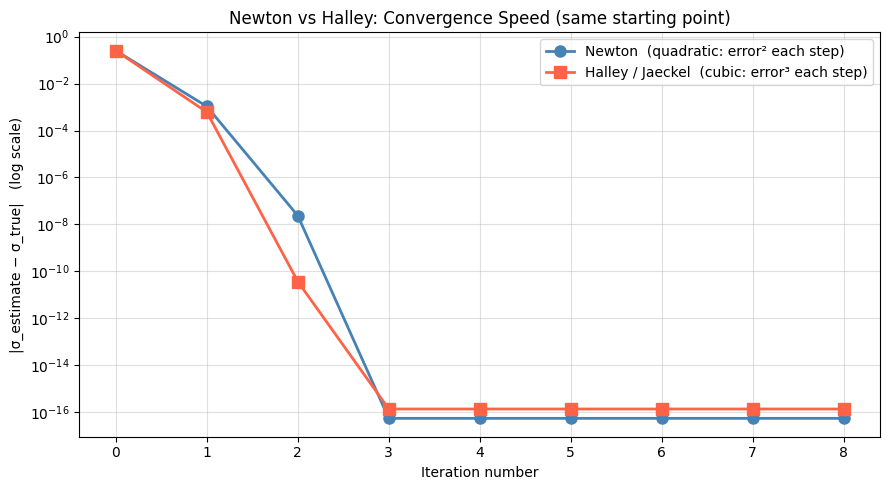

In [3]:
# root-finding problem: find σ s.t. f(σ) = BS_price(σ) − C_market = 0
# f is strictly increasing in σ (vega > 0 always) → exactly one root

def implied_vol_newton(C_market, S, K, T, r, option_type='call',
                       sigma0=0.2, tol=1e-8, max_iter=50):                # Newton-Raphson: uses the slope (vega) to guide each step toward the root; sigma0 = starting guess; tol = acceptable |f(σ)|; max_iter = safety cap
    sigma = sigma0                                                          # initialise at starting guess (default 20% vol — reasonable for most equity options)
    for _ in range(max_iter):                                              # iterate up to max_iter times; typically converges in 5-6 iterations for well-conditioned problems
        price = bs_price(S, K, T, r, sigma, option_type)                  # evaluate BS price at current σ guess
        diff  = price - C_market                                           # f(σ) = BS_price − market price; want this → 0
        if abs(diff) < tol:                                                # found the root within a certain tolerance of the horiz axis, stop 
            return sigma
        d1   = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))  # d1 needed to compute vega (the derivative f'(σ))
        vega  = S * np.sqrt(T) * norm.pdf(d1)                             # vega = f'(σ) = ∂BS/∂σ; the "slope" of the BS price curve at current σ; NOT divided by 100 (we need the raw derivative, not the "per 1%" version)
        if abs(vega) < 1e-12:                                              # vega ≈ 0 means the BS price is nearly flat here (deep OTM near expiry); σ − f/vega → ∞, so abort to avoid blowing up
            break
        sigma -= diff / vega                                               # Newton update: σ_{n+1} = σ_n − f(σ_n)/f'(σ_n); move toward the root by the ratio of "how wrong we are" to "how fast the curve is moving"
        sigma  = max(sigma, 1e-8)                                          # clamp to positive: vol must be > 0 (otherwise d1 and d2 are undefined)
    return sigma                                                            # return best estimate even if tol not reached


def implied_vol_brent(C_market, S, K, T, r, option_type='call', tol=1e-8): # Brent's method: combines bisection (guaranteed) + secant (fast) + IQI (faster); always converges from any starting bracket
    low, high = 1e-4, 5.0                                                  # initial bracket: [0.01% vol, 500% vol]; BS price is monotone in σ so any real market price has exactly one root in this interval
    f_low  = bs_price(S, K, T, r, low,  option_type) - C_market          # f(low) < 0 for any real option (BS at 0.01% vol ≈ intrinsic value, almost always < market price)
    f_high = bs_price(S, K, T, r, high, option_type) - C_market          # f(high) > 0 (BS at 500% vol greatly exceeds any real market price); opposite signs confirm root is inside the bracket

    a, fa = low,  f_low                                                    # a = left endpoint of bracket
    b, fb = high, f_high                                                   # b = right endpoint; Brent's invariant: f(a)·f(b) < 0 (opposite signs, root between them)
    if abs(fa) < abs(fb):                                                  # enforce |f(b)| ≤ |f(a)|: b should always be the "better" (closer to zero) endpoint; swap if needed
        a, b, fa, fb = b, a, fb, fa
    c,  fc  = a, fa                                                        # c = previous value of b; we keep three (σ, f) pairs for IQI (needs 3 distinct points)
    mflag   = True                                                          # mflag: whether the last step was bisection; used in acceptance conditions to decide if the next fast step is making enough progress
    d       = 0.0                                                           # d = c from two steps ago; needed for one of the progress-check conditions

    for _ in range(1000):                                                  # safety cap at 1000; in practice Brent converges in ~50 or fewer
        if abs(fb) < tol or abs(b - a) < tol:                             # converged: either |f(b)| < tol (close enough to zero) OR bracket [a,b] is smaller than tol
            return b                                                        # b is always our best point, return it

        if fa != fc and fb != fc:                                          # IQI needs 3 distinct f-values; skip IQI on the first iteration when c=a so fa=fc
            s = (a * fb * fc / ((fa - fb) * (fa - fc)) +                  # Inverse Quadratic Interpolation (IQI): fit a unique parabola through (a,fa),(b,fb),(c,fc) in the "inverse" direction — σ as a function of f-value; find σ where the parabola = 0; faster convergence than a line when the function curves
                 b * fa * fc / ((fb - fa) * (fb - fc)) +
                 c * fa * fb / ((fc - fa) * (fc - fb)))
        else:
            s = b - fb * (b - a) / (fb - fa)                              # secant: draw a line through (a,fa) and (b,fb), find where it crosses zero; faster than bisection but can leave the bracket

        lo    = min((3*a + b)/4, b)                                        # define the "acceptable zone" for the fast step: must land in (3a/4+b/4, b), the inner portion of the bracket near b
        hi    = max((3*a + b)/4, b)
        cond1 = not (lo < s < hi)                                          # step lands outside acceptable zone → too far, reject
        cond2 = mflag       and abs(s - b) >= abs(b - c) / 2              # last step was bisection but new step isn't at least as fast → not making enough progress, reject
        cond3 = (not mflag) and abs(s - b) >= abs(c - d) / 2             # same check for non-bisection last step
        cond4 = mflag       and abs(b - c) < tol                          # bracket already tiny in bisection mode → numerical issues possible, reject
        cond5 = (not mflag) and abs(c - d) < tol                          # same in non-bisection mode
        if cond1 or cond2 or cond3 or cond4 or cond5:                     # any rejection → fall back to bisection
            s, mflag = (a + b)/2, True                                     # bisection: always safe, always halves bracket, never fails
        else:
            mflag = False                                                   # fast step accepted; note this for next iteration's progress check

        fs = bs_price(S, K, T, r, s, option_type) - C_market             # evaluate f at the new point s
        d = c; c, fc = b, fb                                               # shift history forward: d ← old c, c ← old b (keep 3-step history for IQI and acceptance checks)
        if fa * fs < 0:                                                    # opposite signs between a and s → root is in [a, s]
            b, fb = s, fs                                                  # new right endpoint of bracket
        else:                                                               # root is in [s, b]
            a, fa = s, fs                                                  # new left endpoint of bracket
        if abs(fa) < abs(fb):                                              # re-enforce: b should have the smaller |f|
            a, b, fa, fb = b, a, fb, fa

    return b                                                                # return best estimate (should never reach here in practice)


def implied_vol_jaeckel(C_market, S, K, T, r, option_type='call', tol=1e-10): # Jaeckel's method: normalise the problem, compute an analytic initial guess, apply Halley (cubic convergence)
    C_market_orig    = C_market                                            # save original inputs before put-call parity conversion below; needed if we fall back to Brent at the end
    option_type_orig = option_type

    if option_type == 'put':                                               # puts and calls contain identical σ information; convert puts to equivalent calls via parity
        C_market = C_market + S - K * np.exp(-r * T)                      # put-call parity: C = P + S − K·e^{-rT}; rearranging recovers the call price; the implied vol is the same for both at the same (K, T)

    F        = S * np.exp(r * T)                                           # forward price: F = S·e^{rT} = the risk-neutral expectation of S_T; under risk-neutral measure, E^Q[S_T] = F
    discount = np.exp(-r * T)                                              # discount factor: present value of $1 at time T
    beta     = C_market / (discount * np.sqrt(F * K))                     # normalised call price β = C·e^{rT}/√(FK); this dimensionless number depends ONLY on (x, θ)
    x        = np.log(F / K)                                               # log-moneyness x = log(F/K); x=0 is ATM; x>0 is ITM call; x<0 is OTM call; the whole normalised formula depends only on x and θ

    beta_intrinsic = max(np.exp(x/2) - np.exp(-x/2), 0.0)                # normalised intrinsic value = 2·sinh(x/2) for x>0, 0 for x≤0; no-arbitrage says option price ≥ intrinsic value (otherwise buy-exercise-sell for free money)
    beta_tv = beta - beta_intrinsic                                      # time value = normalised price minus intrinsic; this is what depends on σ and T, what we're actually solving for

    if beta_tv <= 0:                                                       # option at or below intrinsic: market implies σ ≈ 0 (or bad quote)
        return 1e-8                                                        # return near-zero vol; 1e-8 to avoid division-by-zero downstream

    eps = 0.01                                                             # ATM threshold: |x| < 0.01 means forward and strike differ by less than 1%; use the ATM approximation here
    if abs(x) < eps:                                                       # near ATM: both N(d1) and N(d2) ≈ 0.5; the BS formula simplifies to β_TV ≈ θ/√(π/2)
        theta_init = np.sqrt(2.0 * np.pi) * beta_tv                       # ATM initial guess: inverts β_TV ≈ θ·√(2/π) → θ = β_TV·√(2π); this comes from the small-argument expansion N(z) ≈ 0.5 + z/√(2π)

    elif x < 0:                                                            # OTM call: d2 very negative so N(d2)≈0, the second term in β vanishes; only the N(d1) term matters
        u = np.clip(beta_tv * np.exp(-x / 2), 1e-12, 1 - 1e-12)         # u = β_TV·e^{-x/2} ≈ N(d1) = N(x/θ + θ/2); clip to (0,1) so norm.ppf doesn't blow up at boundaries
        y = norm.ppf(u)                                                    # y = Φ^{-1}(u) ≈ d1 = x/θ + θ/2; inverse normal CDF gives us what d1 must equal
        theta_init = y + np.sqrt(max(y**2 - 2*x, 0.0))                   # solve the quadratic x/θ + θ/2 = y → θ² − 2yθ − 2x = 0 → θ = y + √(y²−2x); discriminant y²−2x > 0 because x<0

    else:                                                                   # ITM call (x>0): N(d1)≈1, time value is driven by the N(-d2) term (the put-like term); arises when a deep OTM put was converted via put-call parity
        u = np.clip(beta_tv * np.exp(x / 2), 1e-12, 1 - 1e-12)          # u = β_TV·e^{x/2} ≈ N(-d2) = N(-x/θ + θ/2)
        y = norm.ppf(u)                                                    # y = Φ^{-1}(u) ≈ -d2 = -x/θ + θ/2
        theta_init = y + np.sqrt(max(y**2 + 2*x, 0.0))                   # solve quadratic -x/θ + θ/2 = y → θ² − 2yθ − 2x = 0 → θ = y + √(y²+2x); discriminant y²+2x > 0 because x>0

    sigma = np.clip(abs(theta_init) / np.sqrt(T), 1e-6, 5.0)             # recover σ from θ: θ=σ√T → σ=θ/√T; clip to [0.0001%, 500% vol] to keep Halley's iterations in a sensible range

    for _ in range(10):                                                    # Halley iterations; cubic convergence means 3-5 steps almost always gives machine precision
        price = bs_price(S, K, T, r, sigma, 'call')                       # evaluate f(σ) = BS_call(σ) − C_market (always in call space since we converted puts earlier)
        diff  = price - C_market                                           # f(σ): how far off we are; want this → 0
        if abs(diff) < tol:                                                # converged — return
            return sigma
        d1    = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma * np.sqrt(T)) # d1 for computing f' and f''
        d2    = d1 - sigma * np.sqrt(T)                                    # d2 for the second-derivative formula
        vega  = S * np.sqrt(T) * norm.pdf(d1)                             # f' = vega = ∂BS/∂σ (raw, not scaled by 100)
        if abs(vega) < 1e-12:                                              # vega → 0 means flat curve at this σ; Halley step undefined; fall through to Brent fallback
            break
        vega2 = vega * d1 * d2 / sigma                                    # f'' = ∂²BS/∂σ² = vega·d1·d2/σ; standard BS second-derivative result (chain rule on the vega formula)
        denom = 1.0 - (diff * vega2) / (2.0 * vega**2)                   # Halley denominator = 1 − f·f''/(2f'^2); when f''=0 (linear BS curve) denom=1 and Halley = Newton; when f curves, the correction bends the Newton step toward the root
        sigma -= (diff / vega) / denom if abs(denom) > 1e-12 else diff / vega  # Halley step = Newton step divided by curvature correction; if denom≈0, fall back to plain Newton
        sigma  = max(sigma, 1e-8)                                          # keep σ positive

    if abs(bs_price(S, K, T, r, sigma, 'call') - C_market) > tol * 100:  # final check: did Halley actually converge? if not, use Brent as guaranteed backstop
        return implied_vol_brent(C_market_orig, S, K, T, r, option_type_orig, tol=tol)

    return sigma


S_t, K_t, T_t, r_t, sigma_true = 100.0, 105.0, 0.5, 0.05, 0.25          # known option parameters; we'll price it at sigma_true then try to recover sigma_true from the price
C_t = bs_price(S_t, K_t, T_t, r_t, sigma_true, 'call')                   # exact BS price at the true vol — this becomes our "market price" to invert

iv_n = implied_vol_newton (C_t, S_t, K_t, T_t, r_t)                      # recover σ using Newton
iv_b = implied_vol_brent  (C_t, S_t, K_t, T_t, r_t)                      # recover σ using Brent
iv_j = implied_vol_jaeckel(C_t, S_t, K_t, T_t, r_t)                      # recover σ using Jaeckel/Halley

print(f"True sigma:      {sigma_true:.10f}")
print(f"Newton:          {iv_n:.10f}   error: {abs(iv_n-sigma_true):.2e}")  # all three should recover 0.25 to many decimal places
print(f"Brent:           {iv_b:.10f}   error: {abs(iv_b-sigma_true):.2e}")
print(f"Jaeckel/Halley:  {iv_j:.10f}   error: {abs(iv_j-sigma_true):.2e}")

print("\n── edge case tests (Jaeckel) ─────────────────────────────────────────────")
cases = [
    ("ATM call",       100, 100,  0.5,  0.05, 0.20, 'call'),
    ("ATM put",        100, 100,  0.5,  0.05, 0.20, 'put'),
    ("Deep OTM call",  100, 130,  0.1,  0.05, 0.30, 'call'),
    ("Deep OTM put",   100,  70,  0.1,  0.05, 0.30, 'put'),
    ("Near-expiry",    100, 100,  0.01, 0.05, 0.25, 'call'),
    ("Long-dated",     100, 100,  2.0,  0.05, 0.15, 'call'),
    ("Deep ITM call",  100,  70,  0.5,  0.05, 0.20, 'call'),
]
for name, S_, K_, T_, r_, sig, otype in cases:
    mkt = bs_price(S_, K_, T_, r_, sig, otype)                             # price at known true vol
    iv  = implied_vol_jaeckel(mkt, S_, K_, T_, r_, otype)                 # recover that vol from the price
    print(f"  {name:<20} σ_true={sig:.2f}  IV={iv:.6f}  err={abs(iv-sig):.2e}")  # error should be tiny (≤ ~1e-8)

# convergence comparison plot
sigma0_shared = 0.5   # deliberate wrong starting point (true σ=0.25); far enough that cubic vs quadratic rate difference is visible

def track_newton(sigma0, C_market, S, K, T, r, n=8):                      # run n Newton iterations and record σ at each step for plotting
    sigma, hist = sigma0, [sigma0]                                          # initialise with starting guess; hist stores σ values for the convergence plot
    for _ in range(n):
        p  = bs_price(S, K, T, r, sigma)                                   # current BS price
        d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))           # d1 for vega
        v  = S*np.sqrt(T)*norm.pdf(d1)                                     # vega = f'(σ)
        if abs(v)<1e-12: break                                             # flat curve, abort
        sigma = max(sigma-(p-C_market)/v, 1e-8)                           # Newton step
        hist.append(sigma)                                                  # record updated σ
    return hist

def track_halley(sigma0, C_market, S, K, T, r, n=8):                      # same but uses Halley's update rule (adds curvature correction)
    sigma, hist = sigma0, [sigma0]
    for _ in range(n):
        p  = bs_price(S, K, T, r, sigma)
        d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        v  = S*np.sqrt(T)*norm.pdf(d1)                                     # f'
        v2 = v*d1*d2/sigma                                                 # f''  (curvature of the BS price curve)
        if abs(v)<1e-12: break
        dn = 1.0-(p-C_market)*v2/(2.0*v**2)                               # Halley denominator = 1 − f·f''/(2f'^2)
        sigma = max(sigma-(p-C_market)/v/(dn if abs(dn)>1e-12 else 1), 1e-8)  # Halley step; fall back to Newton if denom≈0
        hist.append(sigma)
    return hist

nh = track_newton(sigma0_shared, C_t, S_t, K_t, T_t, r_t)               # Newton history from σ=0.5
hh = track_halley(sigma0_shared, C_t, S_t, K_t, T_t, r_t)               # Halley history from same starting point

err_n = [(i, abs(s-sigma_true)) for i, s in enumerate(nh)                 # absolute error at each iteration; filter out machine-epsilon points (can't plot log of ~0)
         if abs(s-sigma_true) > 1e-17]
err_h = [(i, abs(s-sigma_true)) for i, s in enumerate(hh)
         if abs(s-sigma_true) > 1e-17]

fig, ax = plt.subplots(figsize=(9, 5))
if err_n: ax.semilogy(*zip(*err_n), 'o-', color='steelblue', lw=2, ms=8,  # semilogy: linear x (iteration), log y (error); *zip(*err_n) unpacks [(i,e)] pairs into x=[i...], y=[e...]
                       label='Newton  (quadratic: error² each step)')
if err_h: ax.semilogy(*zip(*err_h), 's-', color='tomato',    lw=2, ms=8,
                       label='Halley / Jaeckel  (cubic: error³ each step)')
ax.set_xlabel('Iteration number')
ax.set_ylabel('|σ_estimate − σ_true|   (log scale)')
ax.set_title('Newton vs Halley: Convergence Speed (same starting point)')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


We still got a bit of a problem though, since Black-Scholes assumes constant volatility throughout, meaning that if we take all options on the same stock, different strikes K, same expiry T, and back-solve for the implied vol from each one's market price, we should get the same number every time, because there's only one true volatility.

The problem is if we plot IV (implied vol) on the y-axis against strike price K on the x-axis, we see a phenomenon called the **volatility smile**, where IV is higher for low strikes, and curves down and to the right as the strike price increases.

The main reasons this occurs are firstly, that black swan events (super rare events with massive vol shocks) occur *way* more often than Black-Scholes predicts (see the average American mortgage bill in 2008 as evidence). These big OTM shocks are thus more valuable than Black-Scholes says they are because the market is inflating their price to compensate for the risk of a crash. This perfectly embodies the idea of high kurtosis, or fat tails! The other main "explanation" of this phenomenon is an embodiment of the skewness of the price distribution. Namely, stocks crash much harder than they go up, so put options (in which we want the stock price to go down) with low strikes are much more valuable to insure from crashes than expected, so everyone buys them, and the high demand inflates the price at low IV. Conversely, high strike calls (which pay off only if the stock rockets up) have less demand, so lower IV.

Another important visual is the volatility term structure, where instead of varying the strike, vary the maturity T while fixing the strike. Plot IV vs T. It might look like:
Upward sloping: short-term vol is gentler, long-term vol is higher (market expects more uncertainty further out);
Downward sloping (inverted): short-term vol is high, long-term vol is gentler as things settle down;
Humped: medium-term vol is highest.

SPY current price: $728.99
Available expiries: ('2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-10', '2026-07-17', '2026-07-24', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-11-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')
Smile expiries with data: ['2026-07-02', '2026-07-24', '2026-08-31', '2026-10-16']
Term structure points: 26


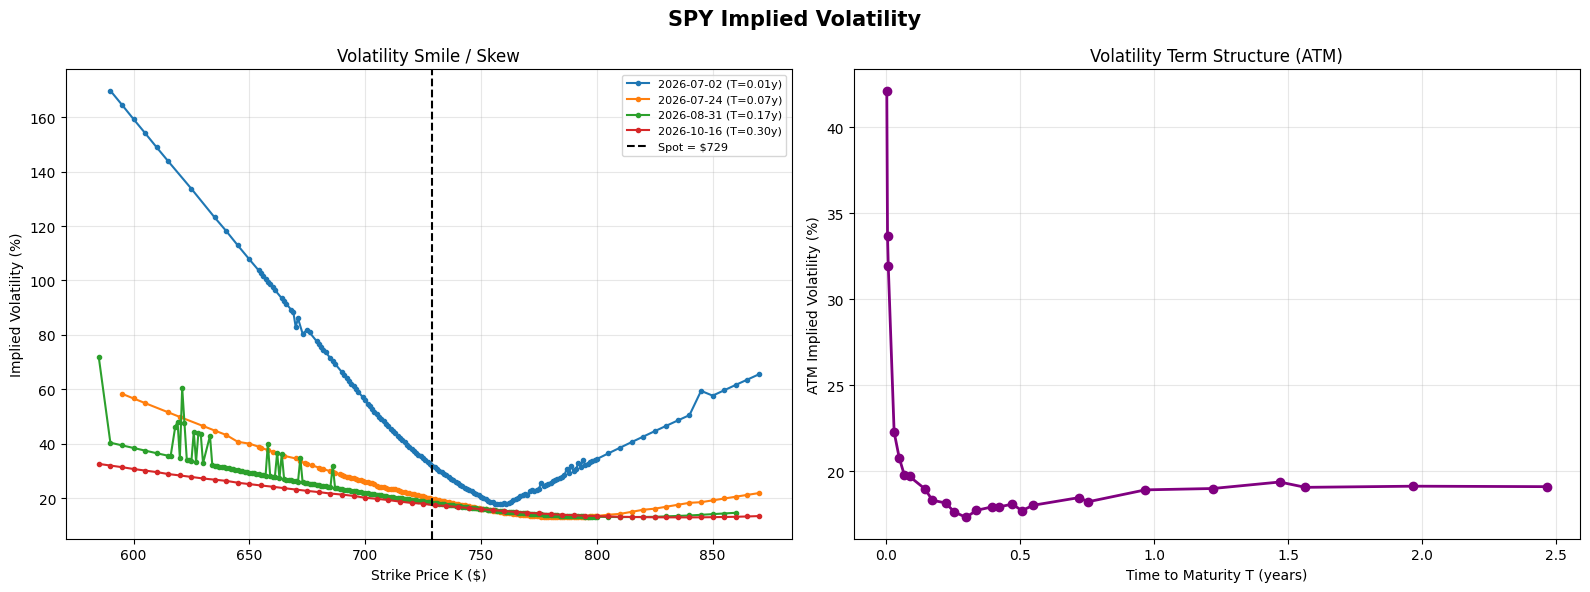

In [4]:
import yfinance as yf                                                      # yfinance: Yahoo Finance Python wrapper; gives us live options chains, stock prices, historical data for any ticker

ticker = yf.Ticker("SPY")                                                  # create a Ticker object for SPY (the S&P 500 ETF); SPY is the ideal options ticker due to most liquid options market in the world, tight bid-ask spreads, hundreds of strikes and expiries available

hist = ticker.history(period="5d")                                         # fetch the last 5 trading days of closing prices; we use "5d" not "1d" because "1d" returns an empty DataFrame on weekends/holidays (no trading = no data)
if hist.empty:                                                              # yfinance returned nothing, internet down or ticker invalid
    raise ValueError("No price data available — check internet connection")
S0 = hist['Close'].iloc[-1]                                                # take the most recent closing price (.iloc[-1] = last row by integer position); this is today's stock price, our spot S in BS

r  = 0.0448                                                                # approximate 3-month US T-bill yield; in BS, r is the continuously-compounded risk-free rate/risk-free drift in the risk-neutral world (all stocks must drift at r, not their historical average, under Q-measure)

print(f"SPY current price: ${S0:.2f}")
print(f"Available expiries: {ticker.options}")                             # show all expiry dates the exchange currently lists for SPY

from datetime import datetime                                               # datetime: converts expiry date strings like "2024-06-21" into date objects so we can compute days-to-expiry

all_expiries = ticker.options                                               # tuple of expiry date strings; our full universe of expiration dates

def get_price(row):                                                        # helper: extract the best available price from one row of an options DataFrame; handles both live and closed market hours
    bid, ask = row['bid'], row['ask']                                      # live bid (what buyers will pay) and ask (what sellers want); mid = fair price estimate when both are active
    if bid > 0 and ask > 0:                                               # both nonzero → live market hours with real quotes
        return (bid + ask) / 2                                             # mid-price: best estimate of fair value between buyer and seller
    last = row['lastPrice']                                                # bid and ask go to 0 after hours/weekends; lastPrice is the last actual trade that happened
    if last > 0:                                                           # a trade occurred at some point
        return last                                                        # use last traded price as the best available stale price
    return 0.0                                                             # no quotes and no trades; no price available

chosen = all_expiries[::3][:5]                                             # pick every 3rd expiry ([::3] = stride 3) and take the first 5 ([:5]); gives 5 well-spaced expirations, enough to see how the smile shape varies with maturity without cluttering the plot

smile_data = {}                                                            # dict: expiry_string → (strikes array, IVs array, T in years); built expiry by expiry below

for expiry in chosen:                                                      # loop over the 5 chosen expirations
    chain = ticker.option_chain(expiry)                                    # fetch the full options chain for this expiry; returns a namedtuple with .calls and .puts DataFrames
    calls = chain.calls                                                    # only need calls; puts give the same IV at every strike by put-call parity

    expiry_date = datetime.strptime(expiry, "%Y-%m-%d")                   # parse "2024-06-21" into a Python datetime object
    T = (expiry_date - datetime.today()).days / 365.0                      # time to expiry in years = calendar days remaining / 365; BS uses years as the time unit

    if T <= 0:                                                             # skip expired contracts (T ≤ 0 means we're at or past expiry)
        continue

    strikes = []                                                           # collect valid strikes for this expiry
    ivs     = []                                                           # collect the corresponding implied vols

    for _, row in calls.iterrows():                                        # iterate over every row of the calls DataFrame; _ discards the DataFrame index, row is a Series
        K         = row['strike']                                          # strike price of this contract
        mid_price = get_price(row)                                         # best available price using our helper

        if mid_price <= 0:                                                 # no usable price → skip
            continue

        if not (0.80 * S0 <= K <= 1.20 * S0):                            # keep only strikes within 80-120% of spot; far OTM options have tiny premiums, huge relative spreads, and very noisy IVs that would distort the smile shape
            continue

        lower_bound = max(S0 - K * np.exp(-r*T), 0)                      # no-arbitrage lower bound on a call = max(S − K·e^{-rT}, 0); a price below this floor implies a free-money arbitrage, so it's a stale or broken quote
        if mid_price <= lower_bound:                                       # price violates the arbitrage bound → skip
            continue

        try:
            iv = implied_vol_brent(mid_price, S0, K, T, r, 'call')      # invert the BS formula: find σ such that BS_call(σ) = mid_price
            if 0.01 < iv < 3.0:                                           # sanity filter: 1% to 300% vol; outside this range the quote is almost certainly a data error
                strikes.append(K)
                ivs.append(iv)
        except:
            continue                                                       # if Newton fails on an illiquid quote, skip silently

    if len(strikes) > 2:                                                   # need at least 3 valid strikes to draw a meaningful curve (2 points = just a line)
        smile_data[expiry] = (np.array(strikes), np.array(ivs), T)        # store as numpy arrays; T is used for the legend label

term_data = []                                                             # list of (T, IV%) pairs; one per expiry; used for the term structure plot

for expiry in all_expiries:                                                # loop over ALL expiries (not just the 5) to get full term structure coverage
    try:
        chain = ticker.option_chain(expiry)
        calls = chain.calls
        expiry_date = datetime.strptime(expiry, "%Y-%m-%d")
        T = (expiry_date - datetime.today()).days / 365.0
        if T <= 0:
            continue

        calls = calls.copy()                                               # copy before adding a column to avoid pandas SettingWithCopyWarning
        calls['dist'] = (calls['strike'] - S0).abs()                      # compute distance from ATM: |K - S0|; we want the strike closest to ATM for the term structure
        candidates = calls.nsmallest(3, 'dist')                           # take the 3 nearest-ATM strikes; try them in order in case the closest has a bad quote

        for _, row in candidates.iterrows():                               # try each candidate
            K         = row['strike']
            mid_price = get_price(row)

            if mid_price <= 0:
                continue
            lower_bound = max(S0 - K * np.exp(-r*T), 0)
            if mid_price <= lower_bound:
                continue

            iv = implied_vol_brent(mid_price, S0, K, T, r, 'call')
            if 0.01 < iv < 3.0:
                term_data.append((T, iv * 100))                           # store (T, IV%); multiply by 100 to convert decimal vol (0.18) to percentage (18%)
                break                                                      # found a valid IV for this expiry; move to the next one
    except:
        continue

term_data.sort(key=lambda x: x[0])                                        # sort by T ascending so the term structure line plots left-to-right from short to long maturity
print(f"Smile expiries with data: {list(smile_data.keys())}")
print(f"Term structure points: {len(term_data)}")

if not smile_data and not term_data:
    print("No valid IV data found — check filters or market hours.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))                       # two side-by-side plots: vol smile (left) and vol term structure (right)
    fig.suptitle('SPY Implied Volatility', fontsize=15, fontweight='bold')

    ax = axes[0]                                                           # left panel: volatility smile
    if smile_data:
        for expiry, (strikes, ivs, T) in smile_data.items():
            ax.plot(strikes, ivs * 100, marker='o', markersize=3,         # plot IV% vs K for each expiry; ivs*100 converts decimal to percent; each expiry gets its own labelled line
                    linewidth=1.5, label=f'{expiry} (T={T:.2f}y)')
        ax.axvline(S0, color='black', linestyle='--',
                   linewidth=1.5, label=f'Spot = ${S0:.0f}')              # dashed black vertical = current spot price = ATM reference
    else:
        ax.text(0.5, 0.5, 'No smile data', transform=ax.transAxes, ha='center')
    ax.set_xlabel('Strike Price K ($)')
    ax.set_ylabel('Implied Volatility (%)')
    ax.set_title('Volatility Smile / Skew')                               # if BS were correct, all lines would be flat; instead we see downward slope ("skew") because low strikes have higher IV (crash insurance demand) and high strikes have lower IV (less demand for OTM calls)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1]                                                           # right panel: vol term structure
    if term_data:
        Ts_term  = [d[0] for d in term_data]                              # extract T values: [d[0] for d in list] = list comprehension over list of tuples
        IVs_term = [d[1] for d in term_data]                              # extract IV% values
        ax.plot(Ts_term, IVs_term, 'o-', color='purple', linewidth=2, markersize=6)  # dots connected by lines; each dot = one expiry's ATM IV; upward slope = calm now, downward slope = stress event, humped = known future event
    else:
        ax.text(0.5, 0.5, 'No term structure data\n(try during market hours)',
                transform=ax.transAxes, ha='center', va='center')
    ax.set_xlabel('Time to Maturity T (years)')
    ax.set_ylabel('ATM Implied Volatility (%)')
    ax.set_title('Volatility Term Structure (ATM)')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


ok so step back. we've built the **volatility smile** (how IV changes across different strikes K, holding maturity fixed) and the **volatility term structure** (how IV changes across different maturities T, holding strike fixed).

the full combined thing that shows those both is the **volatility surface**, where IV plotted simultaneously over a 2D grid of (K, T). think of it like a topographic map where the "elevation" is implied volatility, and the x and y axes are strike price and time to expiry.

why does this matter? because in practice, when we want to price *any* option on a stock, the first thing we need is the implied vol to plug into Black-Scholes (remember: the price is a direct function of sigma, and sigma is not directly observable). the vol surface is where we look it up. we go to (K=105, T=0.5), read off IV=18%, plug it into BS, and that's our fair price.

the other reason this is important is that BS assumes a **flat** vol surface (the same sigma for every (K, T) pair). so if we plot the real market surface and it's *not* flat (and it never is), that's the market saying BS is wrong, and the shape of the surface tells we *how* and *where* BS is wrong.

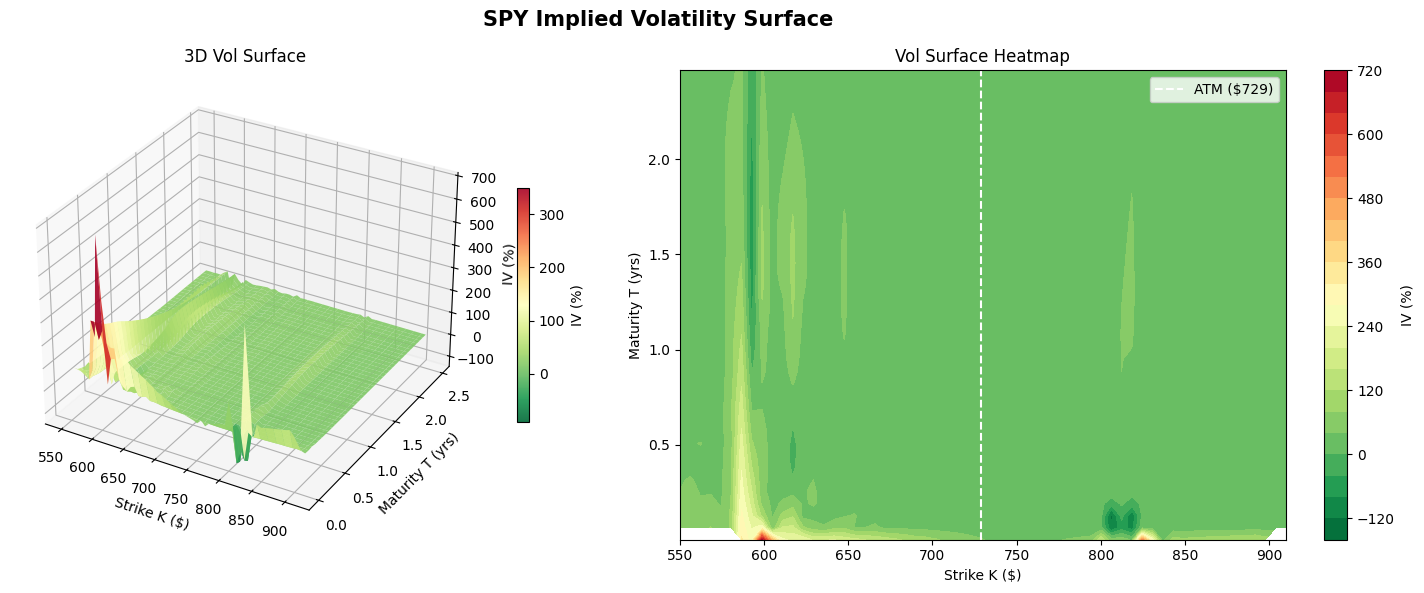

In [5]:
from scipy.interpolate import griddata                                     # griddata: interpolates scattered (x,y,z) data onto a regular rectangular grid; needed because exchange options are only listed at discrete (K, T) combinations, not on a uniform grid

surface_data = []                                                          # will collect (K, T, IV%) triples, one per valid option contract across all strikes and expiries

for expiry in all_expiries:                                                # loop over EVERY available expiry to maximise coverage of the T-axis on the surface
    chain = ticker.option_chain(expiry)                                    # fetch the options chain for this expiry
    calls = chain.calls                                                    # only use calls; puts give the same IV
    expiry_date = datetime.strptime(expiry, "%Y-%m-%d")                   # parse date string to datetime
    T = (expiry_date - datetime.today()).days / 365.0                      # time to expiry in years
    if T <= 0:                                                             # skip expired contracts
        continue

    for _, row in calls.iterrows():                                        # loop over every call at this expiry
        K         = row['strike']                                          # strike price
        bid, ask  = row['bid'], row['ask']                                 # live bid and ask quotes
        mid_price = (bid + ask) / 2                                        # mid = best estimate of fair value when both quotes are live; for the surface we only use live prices (not lastPrice fallback) to keep the data clean

        if mid_price <= 0 or (bid == 0 and ask == 0):                     # zero mid or both quotes zero → no live market for this contract; skip
            continue
        if not (0.75 * S0 <= K <= 1.25 * S0):                            # 75-125% range (wider than the smile plot) to show more of the surface; still exclude far OTM where IVs are too noisy
            continue

        lower_bound = max(S0 - K * np.exp(-r * T), 0)                    # no-arbitrage lower bound on a call; prices below this are stale/broken quotes
        if mid_price <= lower_bound:
            continue

        try:
            iv = implied_vol_brent(mid_price, S0, K, T, r, 'call')      # compute implied vol from the mid price
            if 0.01 < iv < 3.0:                                           # filter out garbage IVs
                surface_data.append((K, T, iv * 100))                     # store (strike, time, IV%) as a tuple
        except:
            continue

if not surface_data:
    print("No surface data found. Markets might be closed or filters too strict.")
else:
    Ks  = np.array([d[0] for d in surface_data])                         # extract all strikes as a numpy array
    Ts  = np.array([d[1] for d in surface_data])                         # extract all times to expiry
    IVs = np.array([d[2] for d in surface_data])                         # extract all IV% values

    K_grid = np.linspace(Ks.min(), Ks.max(), 60)                         # regular 1D grid of 60 evenly-spaced strikes from the minimum to maximum observed strike
    T_grid = np.linspace(Ts.min(), Ts.max(), 40)                         # regular 1D grid of 40 evenly-spaced T values from nearest to furthest expiry
    KK, TT = np.meshgrid(K_grid, T_grid)                                  # meshgrid: turns 1D K_grid (60,) and T_grid (40,) into 2D arrays KK and TT each of shape (40,60); KK[i,j]=K_grid[j], TT[i,j]=T_grid[i]; every (i,j) pair is one grid point
    IV_grid = griddata((Ks, Ts), IVs, (KK, TT), method='cubic')          # interpolate: given our scattered (K,T)→IV cloud, estimate IV at every point of the regular (KK,TT) grid using cubic interpolation (smooth, no kinks between triangles)

    fig = plt.figure(figsize=(16, 6))
    fig.suptitle('SPY Implied Volatility Surface', fontsize=15, fontweight='bold')

    ax3d = fig.add_subplot(121, projection='3d')                          # left subplot as 3D axes; 121 = 1 row, 2 cols, position 1; projection='3d' enables 3D rendering
    surf = ax3d.plot_surface(KK, TT, IV_grid, cmap='RdYlGn_r', alpha=0.9)  # draw the interpolated IV surface in 3D; cmap='RdYlGn_r' = red (high IV) to green (low IV); the left wing (low K) should appear red = crash protection demand raises IV
    ax3d.set_xlabel('Strike K ($)')
    ax3d.set_ylabel('Maturity T (yrs)')
    ax3d.set_zlabel('IV (%)')
    ax3d.set_title('3D Vol Surface')
    fig.colorbar(surf, ax=ax3d, shrink=0.5, label='IV (%)')               # colour bar lets us read IV values from colours; shrink=0.5 makes it half the default height so it fits neatly

    ax2d = fig.add_subplot(122)                                           # right subplot as regular 2D axes; position 2
    hm = ax2d.contourf(KK, TT, IV_grid, levels=20, cmap='RdYlGn_r')     # contourf = filled contour plot: 20 colour bands between min and max IV; "top-down view" of the 3D surface projected onto the (K,T) plane; contour lines connect points of equal IV like topographic contours
    ax2d.axvline(S0, color='white', linestyle='--',
                 linewidth=1.5, label=f'ATM (${S0:.0f})')                 # white dashed vertical = current spot price = the ATM column in the heatmap
    ax2d.set_xlabel('Strike K ($)')
    ax2d.set_ylabel('Maturity T (yrs)')
    ax2d.set_title('Vol Surface Heatmap')
    ax2d.legend()
    fig.colorbar(hm, ax=ax2d, label='IV (%)')                             # colour bar for the heatmap

    plt.tight_layout()
    plt.show()


alright let's talk about the greeks properly. we've defined them mathematically, but let's think about *why we care* about them in practice.

imagine we've bought a call option. the stock moves $1 upward. how much does our option value change? that's **delta**, which tells us our exposure to the stock's movement. if delta is 0.6, our option gained $0.60 when the stock gained $1.

but delta itself changes as the stock moves. if the stock keeps going up, the call gets deeper in-the-money, and delta creeps toward 1 (the option is basically just tracking the stock). if the stock tanks, the call goes out-of-the-money and delta creeps toward 0 (the option barely moves at all). the *rate* at which delta changes with S is called **gamma**, the second derivative of option price with respect to S, or equivalently, the derivative of delta.

**theta** is the daily loss in option value just from time passing, holding everything else fixed. options are "wasting assets", meaning the right to buy at K in 6 months is worth less than the same right with 1 year left, because there's less time for the stock to move in our favor. theta is always negative for a long option position.

**vega** is sensitivity to volatility. for instance, if the market's implied vol suddenly jumps 1%, how much does our option value change? since higher vol means a wider range of possible outcomes, and options benefit from extreme outcomes (we can only exercise if it's worth it), options are always worth more when vol is high. so vega is always positive for a long option.

now here's why we want to see these as *heatmaps* rather than single numbers: the greeks aren't constants. they change as S changes and as T shrinks. a heatmap over (S, T) shows we the full risk landscape of our position.

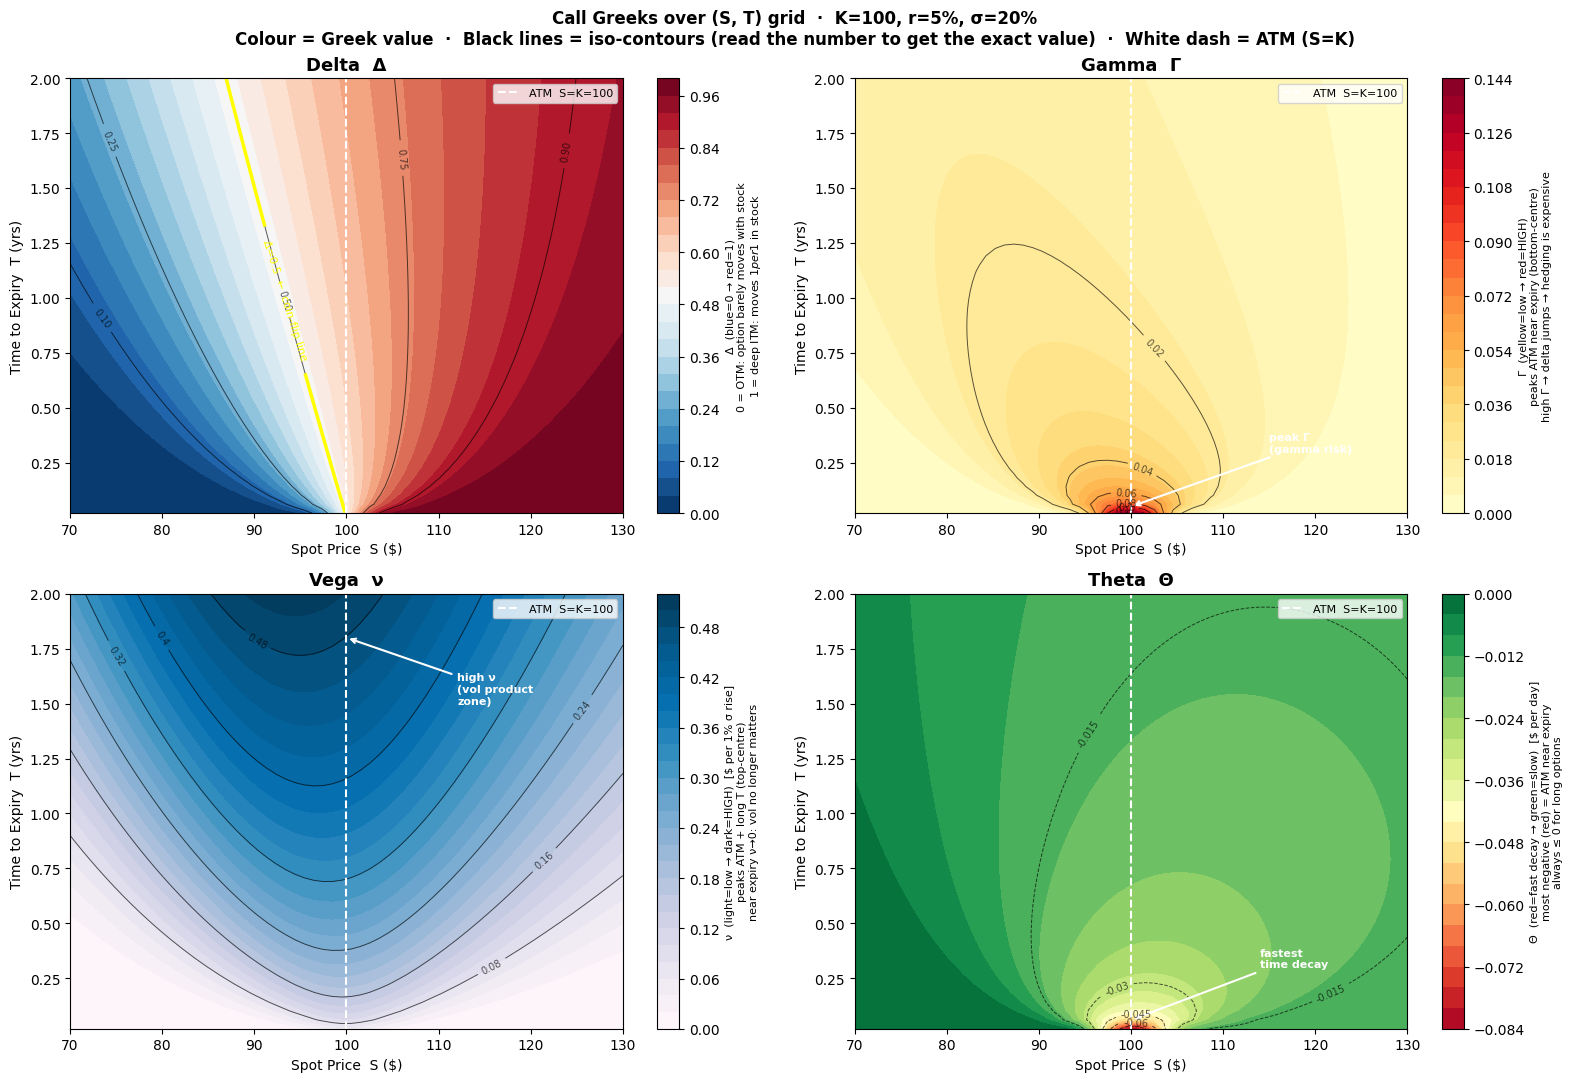

In [ ]:
K_fixed   = 100     # fix the strike so we can study how one specific contract behaves as the stock drifts
sigma_atm = 0.20    # fix vol at 20%; holding σ constant lets (S, T) be the only variables

S_range = np.linspace(70, 130, 60)    # sweep spot $70→$130 (±30% of K=100); 60 points → smooth S-axis
T_range = np.linspace(0.02, 2.0, 50) # sweep T from ~1 week to 2 years; start at 0.02 not 0 because Greeks blow up at T=0

SS, TT = np.meshgrid(S_range, T_range) # expand 1D arrays into 2D grids; SS[i,j]=S_range[j], TT[i,j]=T_range[i]; shape (50,60)

delta_g = np.zeros_like(SS)  # pre-allocate one result value per (S, T) grid point
gamma_g = np.zeros_like(SS)
vega_g  = np.zeros_like(SS)
theta_g = np.zeros_like(SS)

for i in range(SS.shape[0]):       # loop rows → T values
    for j in range(SS.shape[1]):   # loop cols → S values
        g = greeks(SS[i,j], K_fixed, TT[i,j], 0.05, sigma_atm, 'call')
        delta_g[i,j] = g['Delta']  # store each Greek so we can draw it as a 2D colour map
        gamma_g[i,j] = g['Gamma']
        vega_g[i,j]  = g['Vega']
        theta_g[i,j] = g['Theta']

#  HOW TO READ THESE PLOTS
# Each panel is a heatmap of one Greek over the (spot S, time-to-expiry T) plane.
# x-axis = current stock price S; y-axis = time left T; colour = Greek value.
# White dashed line = ATM (S = K = 100).
# Thin black lines = iso-contours — a contour line connects all (S,T) pairs where
#   the Greek equals the number printed on the line, like contour lines on a map.
# Reading a contour label tells you: "everywhere on this curve, the Greek = X."

gr_panels = [
    # DELTA 
    # RdBu_r: blue (cool) = low Δ = OTM option barely reacts to stock moves.
    #          red (warm)  = high Δ = deep ITM option tracks stock dollar-for-dollar.
    # the colour transition is gradual for long T (lots of uncertainty
    #   about where S ends up), but sharpens to an almost vertical knife-edge near
    #   expiry — because with no time left the outcome is almost binary: in or out.
    # Yellow line: Δ = 0.5, the "coin-flip line". Above it you own a synthetic
    #   half-share; below it the option is mostly worthless from a delta perspective.
    (delta_g, 'Delta  Δ', 'RdBu_r',
     'Δ  (blue=0 → red=1)\n'
     '0 = OTM: option barely moves with stock\n'
     '1 = deep ITM: moves $1 per $1 in stock',
     [0.1, 0.25, 0.5, 0.75, 0.9], 'delta'),

    # GAMMA 
    # YlOrRd: yellow = low Γ, orange/red = HIGH Γ.
    # the darkest red is always in the bottom-centre of the plot —
    #   ATM (S≈K) AND short time (T small). That corner is "gamma risk land":
    #   delta changes so fast with S that a small stock move forces large hedge trades.
    # Far OTM (left) or deep ITM (right): Γ≈0 because the option is almost linear there.
    # Long T: Γ is small and spread out; the option is smooth and easy to hedge.
    (gamma_g, 'Gamma  Γ', 'YlOrRd',
     'Γ  (yellow=low → red=HIGH)\n'
     'peaks ATM near expiry (bottom-centre)\n'
     'high Γ → delta jumps → hedging is expensive',
     None, 'gamma'),

    # VEGA 
    # PuBu: light = low ν (vega), dark purple/blue = high ν.
    # darkest region is ATM with LONG time remaining (top-centre).
    #   Long-dated ATM options are "vol products" — their value is almost entirely
    #   driven by σ, not direction. A 1% rise in vol shifts the option price significantly.
    # Near expiry: ν → 0 regardless of S, because there's no time left for vol to matter.
    # Far OTM / deep ITM: ν is low because the vol doesn't change whether we expire in/out.
    (vega_g, 'Vega  ν', 'PuBu',
     'ν  (light=low → dark=HIGH)  [$ per 1% σ rise]\n'
     'peaks ATM + long T (top-centre)\n'
     'near expiry ν→0: vol no longer matters',
     None, 'vega'),

    # THETA 
    # RdYlGn: red = most negative Θ (fastest decay), green = least negative (slowest).
    # deepest red is again bottom-centre — ATM near expiry burns the
    #   fastest. That's the "theta risk" region: you're paying dearly for time value
    #   that's evaporating quickly.
    # Far OTM / deep ITM: Θ ≈ 0 (green) because there was barely any time value to lose.
    # Long T: decay is slower in absolute terms — you pay spread over months, not days.
    (theta_g, 'Theta  Θ', 'RdYlGn',
     'Θ  (red=fast decay → green=slow)  [$ per day]\n'
     'most negative (red) = ATM near expiry\n'
     'always ≤ 0 for long options',
     None, 'theta'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f'Call Greeks over (S, T) grid  ·  K={K_fixed}, r=5%, σ={sigma_atm*100:.0f}%\n'
    f'Colour = Greek value  ·  Black lines = iso-contours (read the number to get the exact value)'
    f'  ·  White dash = ATM (S=K)',
    fontsize=12, fontweight='bold'
)

for ax, (data, name, cmap, cbar_label, c_levels, panel_id) in zip(axes.flatten(), gr_panels):
    # filled colour background 
    cf = ax.contourf(SS, TT, data, levels=25, cmap=cmap)

    # thin labelled iso-contour lines 
    # these let you read the actual Greek value at any (S,T) point,
    # like reading elevation off a topographic map
    if c_levels is not None:
        cs = ax.contour(SS, TT, data, levels=c_levels,
                        colors='black', linewidths=0.7, alpha=0.65)
        ax.clabel(cs, fmt='%.2f', fontsize=7, inline=True)
    else:
        cs = ax.contour(SS, TT, data, levels=7,
                        colors='black', linewidths=0.7, alpha=0.65)
        ax.clabel(cs, fmt='%.3g', fontsize=7, inline=True)

    # panel-specific highlights 
    if panel_id == 'delta':
        # thick yellow line at Δ=0.5: above = option behaves like a stock position
        # below = option is mostly insensitive to the stock
        cs_half = ax.contour(SS, TT, data, levels=[0.5],
                             colors='yellow', linewidths=2.5)
        ax.clabel(cs_half, fmt={0.5: 'Δ=0.5  ←  coin-flip line'},
                  fontsize=8, inline=True)

    elif panel_id == 'gamma':
        # annotate the danger zone: ATM near expiry where Γ peaks
        ax.annotate('peak Γ\n(gamma risk)', xy=(100, 0.05), xytext=(115, 0.3),
                    color='white', fontsize=8, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

    elif panel_id == 'vega':
        # annotate the high-vega "vol product" zone: ATM, long T
        ax.annotate('high ν\n(vol product\nzone)', xy=(100, 1.8), xytext=(112, 1.5),
                    color='white', fontsize=8, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

    elif panel_id == 'theta':
        # annotate the worst-theta zone: ATM, near expiry
        ax.annotate('fastest\ntime decay', xy=(100, 0.06), xytext=(114, 0.3),
                    color='white', fontsize=8, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

    # ATM vertical line
    ax.axvline(K_fixed, color='white', linestyle='--', linewidth=1.5, label=f'ATM  S=K={K_fixed}')

    ax.set_xlabel('Spot Price  S ($)')
    ax.set_ylabel('Time to Expiry  T (yrs)')
    ax.set_title(name, fontsize=13, fontweight='bold', pad=6)
    ax.legend(fontsize=8)

    cb = fig.colorbar(cf, ax=ax)
    cb.set_label(cbar_label, fontsize=8)

plt.tight_layout()
plt.show()


so far we've been thinking about single options, but that's not really how options are actually used. the real power of options is *combining* them to express very specific views about the market, with customizable risk/reward profiles that we just can't get from trading the stock directly.

the core idea is that since we can price any option with BS, and since a strategy is just a portfolio of options, the total P&L of a strategy at expiry is just the sum of each individual leg's payoff, minus the total premium paid to enter.

let's go through the strategies we'll build:

**long call**: pay a premium now. if the stock goes up past the strike, we profit. if not, we lose the premium. straightforward directional bet with capped downside.

**long put**: same idea but for a downward move. classic crash insurance.

**covered call**: we already own the stock. we sell a call against it, collecting premium in exchange for agreeing to sell our shares at the strike if the stock goes above it. we're generating income but capping wer upside. works when we're neutral to mildly bullish.

**protective put**: we own the stock but buy a put below the current price. like car insurance — we pay a premium every month (the put premium), and if we crash (stock tanks), the put pays out and limits our loss. above the strike, we just participate in gains minus the insurance cost.

**straddle**: buy both a call and a put at the same strike. we don't care which direction the stock moves — we're betting it moves a *lot*. classic pre-earnings play.

**strangle**: same idea as straddle but with OTM strikes. cheaper to enter (lower premiums since both legs are OTM), but we need an even bigger move to profit.

**bull call spread**: buy a call at K, sell a call at a higher K. the sale reduces our cost, but caps our profit. a cheaper way to make a directional bet when we don't expect a huge upside move.

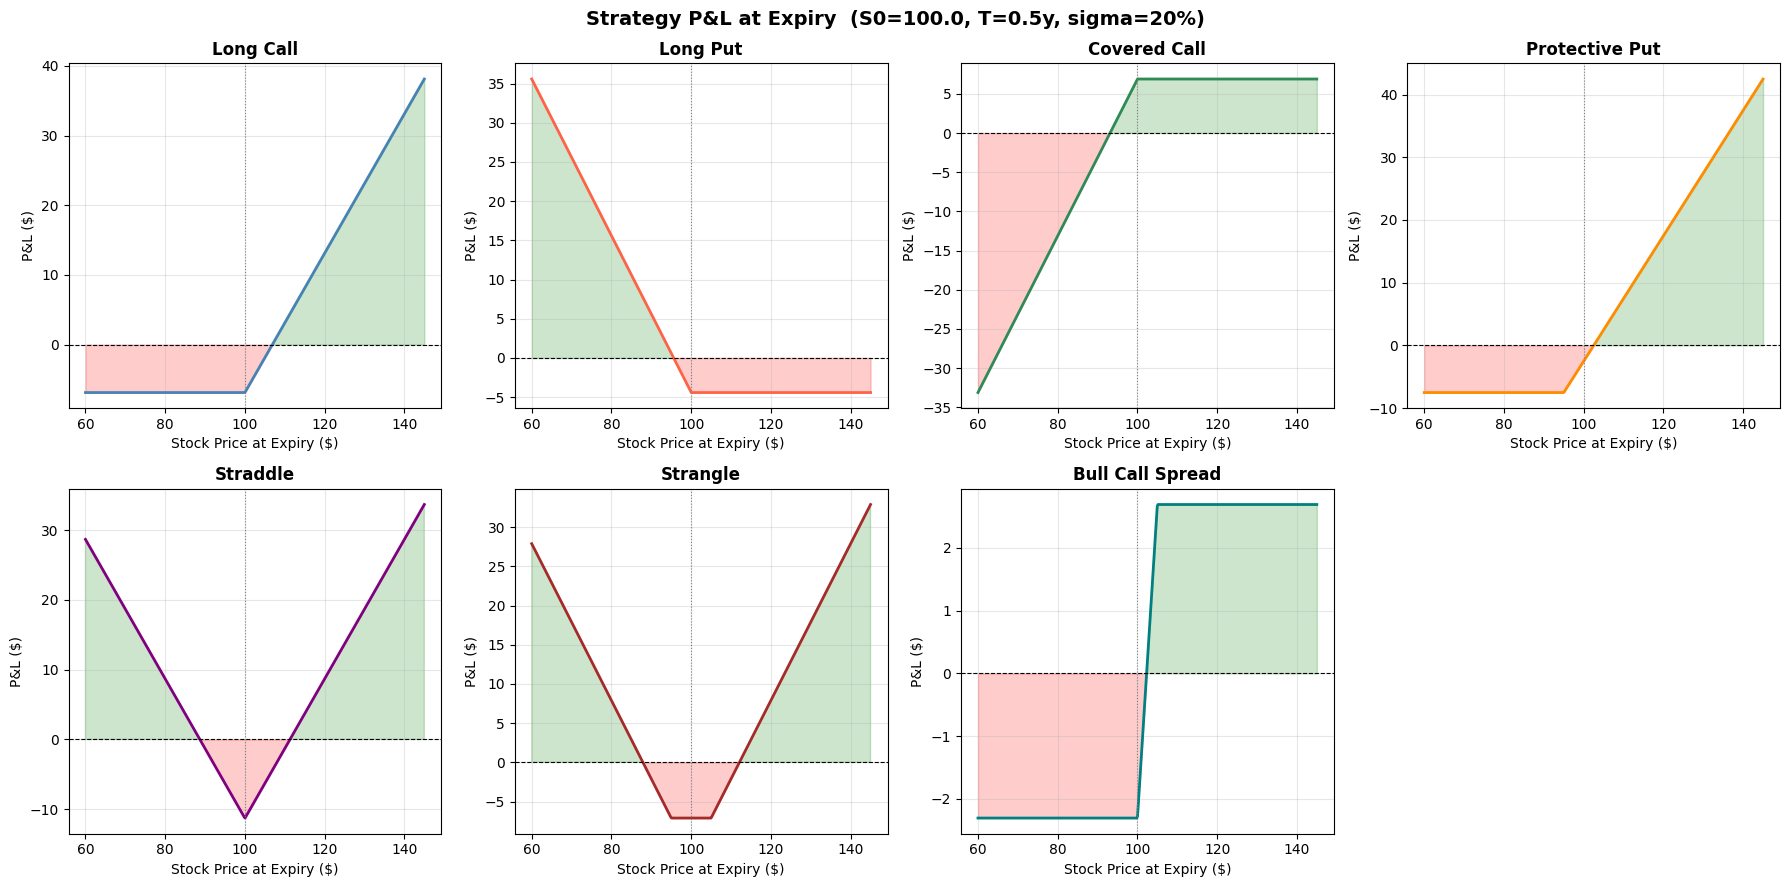

In [ ]:
S0_sim  = 100.0   # starting stock price when we enter the trade
r_sim   = 0.05    # risk-free rate for BS pricing of each option leg
T_sim   = 0.5     # time to expiry: 6 months
sigma_s = 0.20    # assumed vol for pricing all legs (20%)

K_atm   = 100.0   # at-the-money strike = current stock price; used by long call, put, straddle, covered call, bull spread
K_otm_c = 105.0   # out-of-the-money call strike (5% above spot); used in strangle and bull spread
K_otm_p =  95.0   # out-of-the-money put strike (5% below spot); used in protective put and strangle

p_atm_call  = bs_price(S0_sim, K_atm,   T_sim, r_sim, sigma_s, 'call')   # BS price of ATM call = upfront premium; you PAY this if you buy the call, or RECEIVE it if you sell it
p_atm_put   = bs_price(S0_sim, K_atm,   T_sim, r_sim, sigma_s, 'put')    # BS price of ATM put
p_otm_call  = bs_price(S0_sim, K_otm_c, T_sim, r_sim, sigma_s, 'call')   # BS price of OTM call (cheaper than ATM because lower probability of expiring in the money)
p_otm_put   = bs_price(S0_sim, K_otm_p, T_sim, r_sim, sigma_s, 'put')    # BS price of OTM put

ST_range = np.linspace(60, 145, 500)   # 500 evenly-spaced stock prices from $60 to $145; we evaluate the P&L at each one to draw the payoff diagram

def payoff_at_expiry(ST, strategy):                                        # compute net P&L (payoff minus entry cost) at expiry for a given strategy, over an array of terminal stock prices ST
    if strategy == 'Long Call':
        return np.maximum(ST - K_atm, 0) - p_atm_call                    # call pays max(S_T-K,0); subtract the premium paid; profit starts when S_T > K + premium (breakeven); max loss = premium; upside unlimited

    if strategy == 'Long Put':
        return np.maximum(K_atm - ST, 0) - p_atm_put                     # put pays max(K-S_T,0); profit when S_T < K - premium; max gain = K - premium (stock can only fall to zero); unlike call, upside is capped

    if strategy == 'Covered Call':
        return (ST - S0_sim) - (np.maximum(ST - K_atm, 0) - p_atm_call)  # long stock (gain S_T-S0) plus short call (collected premium, owe exercise value); if S_T>K, buyer exercises and you miss gains above K; below K the call expires worthless, you keep the full premium; net: lower breakeven, capped upside at K

    if strategy == 'Protective Put':
        return (ST - S0_sim) + (np.maximum(K_otm_p - ST, 0) - p_otm_put) # long stock plus long OTM put as insurance; put kicks in if S_T < K_otm_p, offsetting losses dollar-for-dollar below that level; you absorb losses from S0 down to K_otm_p (the "deductible"); above K_otm_p the put expires worthless

    if strategy == 'Straddle':
        return (np.maximum(ST - K_atm, 0) - p_atm_call) + (np.maximum(K_atm - ST, 0) - p_atm_put)                   # buy BOTH ATM call and ATM put; one is always worthless at expiry; the other pays if stock moved far enough; need |S_T-K| > total_premium to profit; a bet on a BIG MOVE in either direction (classic pre-earnings trade)

    if strategy == 'Strangle':
        return (np.maximum(ST - K_otm_c, 0) - p_otm_call) + (np.maximum(K_otm_p - ST, 0) - p_otm_put)                 # like straddle but OTM strikes; cheaper entry cost (OTM options cost less) but needs an even bigger move — stock must breach K_otm_c above or K_otm_p below; if stock stays in [95,105] both expire worthless

    if strategy == 'Bull Call Spread':
        return (np.maximum(ST - K_atm,   0) - p_atm_call) - (np.maximum(ST - K_otm_c, 0) - p_otm_call)                # buy ATM call, sell OTM call; selling the OTM call gives you p_otm_call in premium (reducing entry cost) but caps your upside at K_otm_c (where the sold call is exercised against you); limited risk, limited reward — good for moderate bullish views

strategies = ['Long Call', 'Long Put', 'Covered Call',
              'Protective Put', 'Straddle', 'Strangle', 'Bull Call Spread']  # the 7 strategies to display
colors = ['steelblue', 'tomato', 'seagreen',
          'darkorange', 'purple', 'brown', 'teal']                         # one distinct colour per strategy

fig, axes = plt.subplots(2, 4, figsize=(18, 9))                           # 2 rows × 4 columns = 8 subplots for 7 strategies (8th will be hidden)
fig.suptitle(f'Strategy P&L at Expiry  (S0={S0_sim}, T={T_sim}y, sigma={sigma_s*100:.0f}%)',
             fontsize=14, fontweight='bold')

for ax, strat, col in zip(axes.flatten(), strategies, colors):             # zip flattened 8-element axes list with 7 strategies and 7 colours; loop ends when strategies runs out (after 7)
    y = payoff_at_expiry(ST_range, strat)                                  # compute P&L at all 500 stock prices for this strategy; y is a 500-element array
    ax.plot(ST_range, y, color=col, linewidth=2)                           # draw the P&L curve; x = stock price at expiry, y = net P&L
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')           # horizontal black dashed at P&L=0; segments above = profit, segments below = loss
    ax.axvline(S0_sim, color='grey', linewidth=0.8, linestyle=':')        # grey dotted vertical at S0 = stock price when we entered the position
    ax.fill_between(ST_range, y, 0, where=(y > 0), alpha=0.2, color='green')  # shade profit zone green; where=(y>0) restricts fill to profitable outcomes; alpha=0.2 for transparent overlay
    ax.fill_between(ST_range, y, 0, where=(y < 0), alpha=0.2, color='red')    # shade loss zone red
    ax.set_title(strat, fontweight='bold')
    ax.set_xlabel('Stock Price at Expiry ($)')
    ax.set_ylabel('P&L ($)')
    ax.grid(True, alpha=0.3)

axes.flatten()[-1].set_visible(False)   # 2×4 = 8 slots, 7 strategies; hide the empty 8th subplot
plt.tight_layout()
plt.show()


the payoff diagrams above show a static picture: "if the stock ends at X, our P&L is Y." but we're holding the position for 6 months before expiry, and during that time the value of our position is constantly changing. the stock is moving, and time is ticking away (theta decay).

this brings up the concept of **mark-to-market (MtM) P&L**: what is the position worth *right now*, if we closed it out today? it's not the terminal payoff; it's the current BS price of each option leg, minus what we paid to enter.

so at any point in time t before expiry, with stock at S and remaining time tau = T - t:
- our long call is worth BS_price(S, K, tau, r, sigma) — this changes every second as S moves and tau shrinks
- our P&L = current position value - what we paid on day 1

Monte Carlo lets us simulate thousands of possible stock paths and watch how each strategy's MtM P&L evolves over time. this reveals things the terminal payoff diagram hides:
- how fast does the straddle *lose* value if the stock just sits still and doesn't move? (theta bleeding)
- how volatile is the P&L path of a covered call vs a long call?
- where in time does most of the risk/reward of the bull spread get realized?

these are the questions that matter for actually *managing* an options position, not just holding it to expiry.

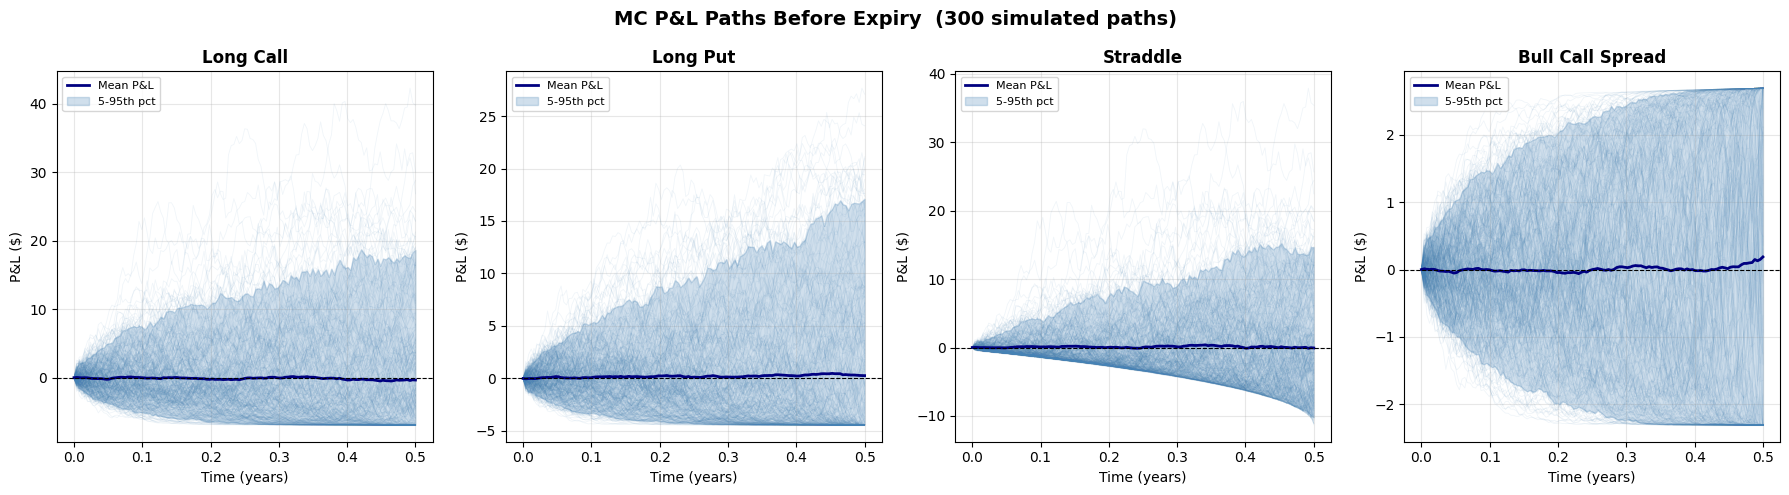

In [ ]:
N_paths = 300                                                              # number of simulated stock price paths; 300 is enough to see the distribution of outcomes without the plot becoming an unreadable blob
N_steps = 126                                                              # time steps per path ≈ 6 months of trading days (252 trading days/year ÷ 2); each step = roughly 1 trading day
dt      = T_sim / N_steps                                                  # size of each time step in years (dt ≈ 0.004 yr ≈ 1 trading day); the smaller dt is, the more accurate the discrete GBM approximation

np.random.seed(42)                                                         # fix random seed → same 300 paths every run; reproducibility is essential when debugging or presenting; remove seed to see different realisations
Z_paths = np.random.standard_normal((N_paths, N_steps))                   # draw a (300, 126) matrix of independent N(0,1) random numbers; each row is one path's sequence of Brownian shocks, one per time step
log_ret = (r_sim - 0.5 * sigma_s**2) * dt + sigma_s * np.sqrt(dt) * Z_paths  # log return over each dt step: (r-σ²/2)·dt + σ·√dt·Z; (r-σ²/2)·dt is the Itô-corrected drift per step; σ·√dt·Z is the random part with std dev σ·√dt; broadcasting over the (300,126) Z array applies the formula to every (path, step) simultaneously
S_paths = S0_sim * np.exp(np.cumsum(log_ret, axis=1))                     # cumulative sum of log-returns along axis=1 (across time for each path) = log(S_t/S0); np.exp converts back to price ratios; multiply by S0_sim gives absolute prices; result shape (300, 126), one price per (path, step)
S_paths = np.hstack([np.full((N_paths, 1), S0_sim), S_paths])            # prepend the starting price S0 as column 0: np.full((300,1), S0) creates a (300,1) column; np.hstack joins horizontally to get (300,127); now S_paths[:,0]=S0 for all paths

t_grid = np.linspace(0, T_sim, N_steps + 1)                               # time axis: 127 evenly-spaced values from t=0 to t=T_sim; lines up exactly with the 127 columns of S_paths

def position_value(S, t, strategy):                                        # compute mark-to-market (MtM) P&L of a strategy at time t when the stock is at S; S can be an array (one value per path) so this is fully vectorised
    tau = T_sim - t                                                        # time REMAINING to expiry; tau = T at t=0, tau = 0 at expiry; used as the T argument in BS pricing
    if tau < 1e-4:                                                         # if we're within ~0.04 days of expiry, treat as expired (avoid √tau→0 numerical issues)
        return payoff_at_expiry(S, strategy)                               # at expiry only intrinsic value matters; payoff_at_expiry handles the whole array S

    if strategy == 'Long Call':
        return bs_price(S, K_atm, tau, r_sim, sigma_s, 'call') - p_atm_call  # MtM P&L = current BS value of the long call (with tau remaining, stock at S) minus the premium we paid on day 0; positive when stock rose or vol increased, negative from theta decay when stock sits still
    if strategy == 'Long Put':
        return bs_price(S, K_atm, tau, r_sim, sigma_s, 'put') - p_atm_put
    if strategy == 'Covered Call':
        return (S - S0_sim) - (bs_price(S, K_atm, tau, r_sim, sigma_s, 'call') - p_atm_call)  # long stock unrealised P&L (S-S0) minus the short-call P&L; the minus sign: we're SHORT the call so when its value rises we LOSE
    if strategy == 'Protective Put':
        return (S - S0_sim) + (bs_price(S, K_otm_p, tau, r_sim, sigma_s, 'put') - p_otm_put)  # long stock plus long put; if stock falls the put's value rises, partially or fully offsetting the stock loss
    if strategy == 'Straddle':
        return (bs_price(S, K_atm, tau, r_sim, sigma_s, 'call') - p_atm_call) +                (bs_price(S, K_atm, tau, r_sim, sigma_s, 'put')  - p_atm_put)   # sum of both long legs' MtM; gains from big stock moves OR from rising vol (both legs have positive vega); loses from theta decay if stock sits still (both legs decay)
    if strategy == 'Strangle':
        return (bs_price(S, K_otm_c, tau, r_sim, sigma_s, 'call') - p_otm_call) +                (bs_price(S, K_otm_p, tau, r_sim, sigma_s, 'put')  - p_otm_put)
    if strategy == 'Bull Call Spread':
        return (bs_price(S, K_atm,   tau, r_sim, sigma_s, 'call') - p_atm_call) -                (bs_price(S, K_otm_c, tau, r_sim, sigma_s, 'call') - p_otm_call)  # long ATM call MtM minus short OTM call MtM; the two legs partially cancel — limited gain above K_otm_c, limited loss below K_atm

sim_strategies = ['Long Call', 'Long Put', 'Straddle', 'Bull Call Spread']  # 4 strategies with the most interesting pre-expiry dynamics to visualise
fig, axes = plt.subplots(1, len(sim_strategies), figsize=(18, 5))         # 1 row, 4 panels side-by-side
fig.suptitle('MC P&L Paths Before Expiry  (300 simulated paths)', fontsize=14, fontweight='bold')

for ax, strat in zip(axes, sim_strategies):
    pnl_paths = np.zeros((N_paths, N_steps + 1))                          # pre-allocate (300, 127) array; pnl_paths[i,j] = P&L of path i at time step j
    for step_i, t in enumerate(t_grid):                                    # loop over each time step; step_i is the index (0..126), t is the time in years
        S_t = S_paths[:, step_i]                                           # slice all 300 paths at time step step_i: S_t is a 300-element array, one price per path
        pnl_paths[:, step_i] = position_value(S_t, t, strat)             # compute MtM P&L for all 300 paths simultaneously; position_value is vectorised so S_t array works

    for path in pnl_paths:                                                 # loop over each of the 300 individual P&L time series
        ax.plot(t_grid, path, alpha=0.08, linewidth=0.6, color='steelblue')  # plot each path very faintly (alpha=0.08 = 8% opacity); 300 overlapping faint lines create a "spaghetti" density plot showing where most outcomes cluster

    mean_pnl = pnl_paths.mean(axis=0)                                     # mean P&L across all 300 paths at each time step; axis=0 = average over paths (rows), result shape (127,)
    p5  = np.percentile(pnl_paths, 5,  axis=0)                            # 5th percentile at each step = worst 5% of outcomes; below this line, 5% of paths end up
    p95 = np.percentile(pnl_paths, 95, axis=0)                            # 95th percentile at each step = best 5% of outcomes; band [p5,p95] contains 90% of all simulated outcomes

    ax.plot(t_grid, mean_pnl, color='navy', linewidth=2, label='Mean P&L')  # bold navy line = expected P&L path; for long options under risk-neutral drift this typically drifts negative (theta eats the position when stock is near ATM)
    ax.fill_between(t_grid, p5, p95, alpha=0.25, color='steelblue',
                    label='5-95th pct')                                    # shaded band = 90% confidence region; wide band = uncertain outcome (high variance); narrow band = predictable
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')           # horizontal breakeven reference
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('P&L ($)')
    ax.set_title(strat, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
